### ANN for regression, example 2, house market data (+ how to handle categorical variables)

### THIS EXAMPLE CONTAINS A VERY COMMON OPTIMIZATION METHOD IN BASIC ANN REGRESSION - BatchNormalization and regularization, see the neural network structure part for details!

#### Imports / modules

In [84]:
# pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics

# pip install tensorflow
import tensorflow as tf
import keras
from keras import layers

from sklearn.impute import KNNImputer

#### Loading the dataset

In [85]:
# load the csv-file to pandas DataFrame
df = pd.read_csv("../datasets/Life Expectancy Data.csv")

In [86]:
# deep learning / neural network-wise, this is a small dataset
len(df)

2938

In [87]:
# quickly check the first few rows of data
# to see what we have here
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [88]:
# let's also fix and unify the spelling of column names (for my own sanity)

# Country,Year,Status,Life expectancy ,Adult Mortality,
# infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles ,
#  BMI ,under-five deaths ,Polio,Total expenditure,Diphtheria , HIV/AIDS,GDP,Population,
#  thinness  1-19 years, thinness 5-9 years,Income composition of resources,Schooling

headers = list(df.columns.values)
new_headers = []

for i in headers:
    clean_text = i.strip()

    if clean_text.isupper():
        new_headers.append(clean_text)

    else:
        new_headers.append(clean_text.title())    

    
print(new_headers)
df.columns = new_headers


['Country', 'Year', 'Status', 'Life Expectancy', 'Adult Mortality', 'Infant Deaths', 'Alcohol', 'Percentage Expenditure', 'Hepatitis B', 'Measles', 'BMI', 'Under-Five Deaths', 'Polio', 'Total Expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'Thinness  1-19 Years', 'Thinness 5-9 Years', 'Income Composition Of Resources', 'Schooling']


### Few more checks for data, any missing values or duplicates

In [89]:
# it seems we don't have any missing values
df.isna().sum()

Country                              0
Year                                 0
Status                               0
Life Expectancy                     10
Adult Mortality                     10
Infant Deaths                        0
Alcohol                            194
Percentage Expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
Under-Five Deaths                    0
Polio                               19
Total Expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
Thinness  1-19 Years                34
Thinness 5-9 Years                  34
Income Composition Of Resources    167
Schooling                          163
dtype: int64

In [90]:
# no duplicates either, it seems
int(df.duplicated().sum())

0

In [91]:
print(f"Statuses: {df['Status'].nunique()}")

Statuses: 2


### Handling the categorical variables

*Type 1: Boolean categories*

In [92]:
# this just converts the value of column to 0 or 1
# factorize in pandas works too, but only one column at a time
from sklearn.preprocessing import LabelEncoder
variables = ['Status']
encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

In [93]:
# quick check that it worked
df

,Country,Year,Status,Life Expectancy,Adult Mortality,Infant Deaths,Alcohol,Percentage Expenditure,Hepatitis B,Measles,...,Polio,Total Expenditure,Diphtheria,HIV/AIDS,GDP,Population,Thinness 1-19 Years,Thinness 5-9 Years,Income Composition Of Resources,Schooling
0,Afghanistan,2015,1,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,1,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,1,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,1,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,1,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,1,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,1,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,1,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,1,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


*Type 2: Ordinal categories*

In [94]:
# no ordinal categories this time (categories with a comparable rank, like 'Low', 'Middle', 'High')
# however, it could perhaps be possible to attempt to use this for the furnishing variable
# but we are going to treat it like a nominal category this time

*Type 3: Nominal categories*

In [95]:
## this makes multiple columns with the variable (Separate for yes/no)
#from sklearn.preprocessing import OneHotEncoder
#variables = ['furnishingstatus']

## use encoder
#encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
#one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
#df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

In [96]:
# we can always remove EXACTLY ONE option per variable when we use OneHotEncoder
#df = df.drop("furnishingstatus_unfurnished", axis=1)

In [97]:
df

,Country,Year,Status,Life Expectancy,Adult Mortality,Infant Deaths,Alcohol,Percentage Expenditure,Hepatitis B,Measles,...,Polio,Total Expenditure,Diphtheria,HIV/AIDS,GDP,Population,Thinness 1-19 Years,Thinness 5-9 Years,Income Composition Of Resources,Schooling
0,Afghanistan,2015,1,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,1,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,1,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,1,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,1,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,1,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,1,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,1,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,1,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [98]:
print(f"Countries: {df['Country'].nunique()}")

Countries: 193


In [99]:
# Because there are 193 countries, we'll drop the column
df = df.drop(["Country", "Year"], axis=1)
df.head()

,Status,Life Expectancy,Adult Mortality,Infant Deaths,Alcohol,Percentage Expenditure,Hepatitis B,Measles,BMI,Under-Five Deaths,Polio,Total Expenditure,Diphtheria,HIV/AIDS,GDP,Population,Thinness 1-19 Years,Thinness 5-9 Years,Income Composition Of Resources,Schooling
0,1,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,1,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,1,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,1,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [100]:
# using an imputer to fill the missing values
knn_imputer = KNNImputer(n_neighbors=5).set_output(transform="pandas")
# imputing the missing value with KNN imputer
df = knn_imputer.fit_transform(df)

# checking that it worked
print(df.isnull().sum())

Status                             0
Life Expectancy                    0
Adult Mortality                    0
Infant Deaths                      0
Alcohol                            0
Percentage Expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
Under-Five Deaths                  0
Polio                              0
Total Expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
Population                         0
Thinness  1-19 Years               0
Thinness 5-9 Years                 0
Income Composition Of Resources    0
Schooling                          0
dtype: int64


#### X/y -split

In [101]:
# perform X/y -split
# if you more than one independent variable, list them all here
# leave out the target variable (dependent variable)

# this is a nice and common trick => everything EXCEPT the target variable => support variables
X = df.drop("Life Expectancy", axis=1)

# have only the target variable here (dependent variable)
y = df['Life Expectancy']

#### Train/test/validation -split

In [102]:
# in Classic ML, we only had train/test -split
# in deep learning, we usually use validation-data also, for better
# optimization possibilities and better metrics

# unfortunately the scikit-learn's train_test_split doesn't support validation
# set split in itself.

# if you want to split the test set into two for a validation set too, try this trick:

# step 1, split the data into 70% (training data) and 30% (temporary data)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)

# step 2, split the temporary data in HALF (0.5) => 15% test and 15% validation
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

#### Create a neural network structure

In [103]:
# create neural network

# save the amount of support variables into a helper variable
# so we don't have to update the input_shape all the time
variable_amount = len(X.columns)

# Define Sequential neural network model
# input shape has to match the amount of SUPPORT VARIABLES
# in other words => amount of columns in X 
# Tip: have at least the same number of nodes as in the input shape
# output layer in regression is always 1 node without activation function

# let's try some common optimization approaches

# neural networks often need at least a normalization layer
# so that it updates all weight values fairly 
# typically the original dataset has various scales of numbers
# which confuses neural network while it's training itself
# luckily we have the BatchNormalization -layer in Keras!

# regularization is often beneficial in neural networks as well
# but Wit's usually better to apply this a bit later
# once you know approximately a working neural network structure for your data

# there are three alternatives for kernel regulaizer => L1, L2 and L1/L2
# you just have to experiment to know which regulazier best suits your model
model = keras.Sequential(
    [
        layers.BatchNormalization(input_shape=(variable_amount,)),
        layers.Dense(16, activation="relu", kernel_regularizer=keras.regularizers.l1(l1=0.1)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ]
)

# select the optimizer and loss function
# you can try rmsprop also as optimizer, or stochastic gradient descent
# loss-function for regression is mse (mean squared error)
model.compile(optimizer='adam', loss='mse')

model.summary()

/home/akka/Documents/vscode_projects/DeepLearning/.venv/lib/python3.12/site-packages/keras/src/layers/normalization/batch_normalization.py:181: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_2           │ (None, 19)             │            76 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,485 (5.80 KB)

 Trainable params: 1,447 (5.65 KB)

 Non-trainable params: 38 (152.00 B)

#### Train the neural network

In [104]:
# train/fit neural network with validation data
# see the instructions on the train/test -split above on how to split the data correctly
model.fit(x=X_train, y=y_train, epochs=500, validation_data=(X_val, y_val))

Epoch 1/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4641.5347 - val_loss: 3366.8787
Epoch 2/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2546.9065 - val_loss: 572.1721
Epoch 3/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 350.9466 - val_loss: 219.2754
Epoch 4/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 162.0960 - val_loss: 132.8362
Epoch 5/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 130.1448 - val_loss: 117.6467
Epoch 6/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 103.5075 - val_loss: 101.9938
Epoch 7/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 94.0638 - val_loss: 97.9450
Epoch 8/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 86.7924 - val_loss: 94.4188
Epoch 9/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 81.9170 - val_loss: 93.3742
Epoch 10/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 74.4950 - val_loss: 87.5699
Epoch 11/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 65.4562 - val_loss: 84.1986
Epoch 12/500
65/65 ━━━━━━━

#### Training metrics in order to see if the model trained an works well

<Axes: >

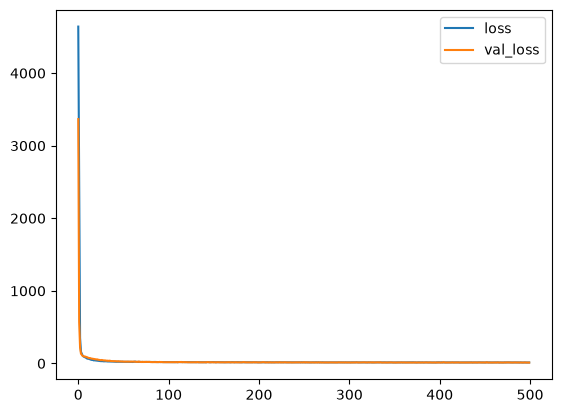

In [105]:
# let's use pandas for this (easy code)
# try to look if the model is actually training 
# => the error is going downwards
# if using validation data, you get two lines
# in this case, see if the lines follow a similar trend 
# (they don't always overlap with complex data, the trend is more important)
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()

In [106]:
# compare the final model loss/evaluation values
print("Test data evaluation:")
print(model.evaluate(X_test, y_test, verbose=0))
print("\nTrain data evaluation:")
print(model.evaluate(X_train, y_train, verbose=0))

Test data evaluation:
11.512078285217285

Train data evaluation:
9.84230899810791


#### Error metrics

In [107]:
# get test predictions
test_predictions = model.predict(X_test)

# reshape the data for easier comparison table
test_predictions = pd.Series(test_predictions.reshape(len(y_test),))
pred_df = pd.DataFrame(np.asarray(y_test), columns=['Test True Y'])
pred_df = pd.concat([pred_df, test_predictions], axis=1)
pred_df.columns = ['Test True Y', 'Model Predictions']

# print the comparison table - true values vs. model predicted values
# we can nicely see here how far off our model is in some cases
pred_df

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,Test True Y,Model Predictions
0,74.8,77.584503
1,73.8,67.909637
2,65.1,61.206619
3,73.2,71.543961
4,77.0,70.391205
...,...,...
436,79.3,78.821693
437,55.3,56.333778
438,73.9,70.767792
439,73.0,74.155495


<Axes: xlabel='Test True Y', ylabel='Model Predictions'>

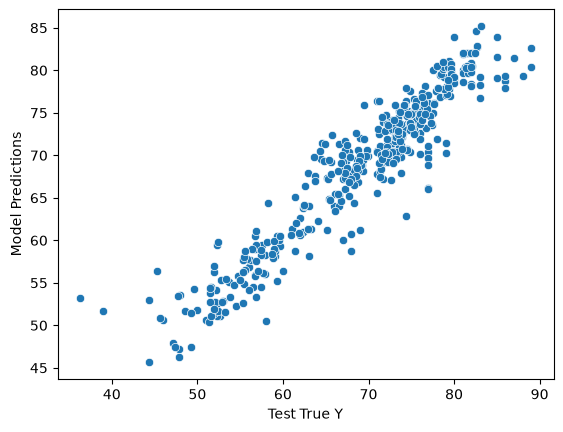

In [108]:
# these values follow a linear diagonal line = good predictions
# we basically compare the predicted values 
# to true test values and see the differences
sns.scatterplot(x='Test True Y', y='Model Predictions', data=pred_df)

In [109]:
# MAE - Mean average error
print("MAE")
print(round(metrics.mean_absolute_error(y_test, test_predictions), 2), "$")

# MSE - Mean square error
print("\nMSE")
print(round(metrics.mean_squared_error(y_test, test_predictions), 2), "$^2")

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(y_test, test_predictions)), 2), "$")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(y_test, test_predictions), 2))

# Explained Variance Score => 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
# high variance score = model is a good fit for the data 
# low variance score = model is not a good fit for the data
# the higher the score, the model is more able to explain the variation in the data
# if score is low, we might need more and better data
print("\nExplained variance score:")
print(round(metrics.explained_variance_score(y_test, test_predictions), 2))

MAE
2.21 $

MSE
9.93 $^2

RMSE:
3.15 $

R-squared:
0.9

Explained variance score:
0.9


/tmp/ipykernel_195847/3124900743.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - test_predictions))


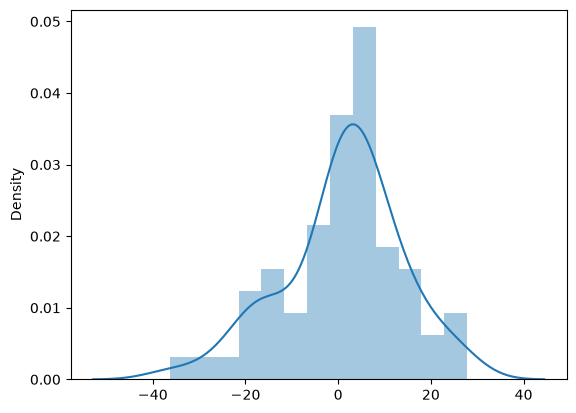

In [110]:
# if the prediction distribution are far from normal distribution
# then the model is not probably good enough
# distplot is deprecating in future pandas-version
# unfortunately, there's no exact alternative to do this plot at the moment
sns.distplot((y_test - test_predictions))
plt.show()
plt.close()

#### Try model in practice (with a new imaginary house)

In [111]:
# just to quickly check what support variables we should include
# in the tester_row -part below
X.columns

Index(['Status', 'Adult Mortality', 'Infant Deaths', 'Alcohol',
       'Percentage Expenditure', 'Hepatitis B', 'Measles', 'BMI',
       'Under-Five Deaths', 'Polio', 'Total Expenditure', 'Diphtheria',
       'HIV/AIDS', 'GDP', 'Population', 'Thinness  1-19 Years',
       'Thinness 5-9 Years', 'Income Composition Of Resources', 'Schooling'],
      dtype='str')

In [112]:
# print a few example houses so we can test with
# the tester row below
df.head(3)

,Status,Life Expectancy,Adult Mortality,Infant Deaths,Alcohol,Percentage Expenditure,Hepatitis B,Measles,BMI,Under-Five Deaths,Polio,Total Expenditure,Diphtheria,HIV/AIDS,GDP,Population,Thinness 1-19 Years,Thinness 5-9 Years,Income Composition Of Resources,Schooling
0,1.0,65.0,263.0,62.0,0.01,71.279624,65.0,1154.0,19.1,83.0,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,1.0,59.9,271.0,64.0,0.01,73.523582,62.0,492.0,18.6,86.0,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,1.0,59.9,268.0,66.0,0.01,73.219243,64.0,430.0,18.1,89.0,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9


In [116]:
# let's try with some new imaginary data
# this example uses the student performance index score dataset
# modify this as needed regarding your own dataset
tester_row = {
    'Status':1,
    'Adult Mortality': 61,
    'Infant Deaths': 11,
    'Alcohol':3.41,
    'Percentage Expenditure':200, 
    'Hepatitis B':9, 
    'Measles':0, 
    'BMI':21,
    'Under-Five Deaths':1, 
    'Polio': 95,
    'Total Expenditure': 6.5, 
    'Diphtheria': 99,
    'HIV/AIDS': 0.1, 
    'GDP': 3558.79, 
    'Population': 1633812.6, 
    'Thinness  1-19 Years': 2.4,
    'Thinness 5-9 Years': 7.8,
    'Income Composition Of Resources': 0.496, 
    'Schooling': 8.6
}

# convert to pandas-format
tester_row = pd.DataFrame([tester_row])

In [120]:
# get the prediction from the model and print out the result
result = model.predict(tester_row)[0][0]

print()
print(f"Predicted life expectancy, with the given parameters:")
print(f"{round(float(result), 2)} years.")
print("----------------------------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

Predicted life expectancy, with the given parameters:
67.3 years.
----------------------------
